# Regime Dataset Construction Research

This notebook researches **ETF + start-date-available proxy universes** for regime-specific backtests. It does **not** use current ETF holdings as historical truth, because historical holdings are unavailable and using today's holdings would introduce survivorship and future-membership bias.

The workflow is:

1. Plot ETF candidates to confirm the desired regime.
2. Download manually seeded stock proxy pools.
3. Screen stocks using availability and liquidity observable before the regime start.
4. Rank candidate proxy universes by regime fit.
5. Print copy-paste TOML snippets for `configs/datasets.toml`.

No cells modify `configs/datasets.toml`.

In [1]:
from __future__ import annotations

import hashlib
import json
import math
import os
import sys
import warnings
from dataclasses import dataclass
from pathlib import Path
from textwrap import indent

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "portfolio_toolkit").exists():
            return candidate
    raise RuntimeError("Could not find Portfolio-Optimizer repo root")


repo_root = find_repo_root()
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from portfolio_toolkit.config import custom_dataset

CACHE_DIR = repo_root / "data_cache" / "regime_research"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.max_rows = 120
pd.options.display.max_columns = 80

print("Repo root:", repo_root)
print("Cache dir:", CACHE_DIR)

Repo root: /Users/adamthorne/Desktop/Portfolio/Portfolio-Optimizer
Cache dir: /Users/adamthorne/Desktop/Portfolio/Portfolio-Optimizer/data_cache/regime_research


## Regime Definitions And Source Notes

The ETF source notes below are for sanity-checking inception dates and avoiding impossible historical windows. The notebook still verifies availability directly from downloaded prices.

In [10]:
SOURCE_NOTES = {
    "XLK": {
        "issuer": "State Street",
        "official_note": "Technology Select Sector SPDR Fund inception Dec 16 1998",
        "url": "https://www.ssga.com/us/en/intermediary/etfs/the-technology-select-sector-spdr-fund-xlk",
    },
    "XLF": {
        "issuer": "State Street",
        "official_note": "Financial Select Sector SPDR Fund inception Dec 16 1998",
        "url": "https://www.ssga.com/mainfund/XLF",
    },
    "MDY": {
        "issuer": "State Street",
        "official_note": "SPDR S&P MidCap 400 ETF Trust inception May 04 1995",
        "url": "https://www.ssga.com/us/en/intermediary/etfs/state-street-spdr-sp-midcap-400-etf-trust-mdy",
    },
    "DIA": {
        "issuer": "State Street",
        "official_note": "SPDR Dow Jones Industrial Average ETF Trust inception Jan 14 1998",
        "url": "https://www.ssga.com/us/en/intermediary/etfs/funds/spdr-dow-jones-industrial-average-etf-trust-dia",
    },
    "XOP": {
        "issuer": "State Street",
        "official_note": "SPDR S&P Oil & Gas Exploration & Production ETF inception Jun 19 2006",
        "url": "https://www.ssga.com/us/en/individual/etfs/funds/spdr-s-p-oil-gas-exploration-production-etf-xop",
    },
    "QQQ": {
        "issuer": "Invesco",
        "official_note": "Invesco QQQ Trust inception Mar 10 1999",
        "url": "https://www.invesco.com/qqq-etf/en/home.html",
    },
    "SMH": {
        "issuer": "VanEck",
        "official_note": "Current VanEck Semiconductor ETF structure should be verified before pre-2011 use; use only where price availability supports the window.",
        "url": "https://www.vaneck.com/us/en/investments/semiconductor-etf-smh/",
    },
}

REGIMES = {
    "modern_tech_gain_2022_2026": {
        "title": "Modern Tech / AI-Led Gain Regime",
        "objective": "gain",
        "target_start": "2022-01-03",
        "target_end": "2026-05-21",
        "benchmark": "XLK",
        "etfs": ["XLK", "QQQ", "SMH"],
        "pool_name": "modern_tech_semis_growth",
        "min_pre_dollar_volume": 10_000_000,
        "min_lookback_days": 252,
        "toml_splits": {
            "start_date": "2014-01-02",
            "end_date": "2026-05-21",
            "train_start": "2014-01-02",
            "train_end": "2019-12-31",
            "val_start": "2020-01-02",
            "val_end": "2021-12-31",
            "test_start": "2022-01-03",
            "test_end": "2026-05-21",
        },
    },
    "financial_crisis_loss_2005_2010": {
        "title": "Financial Crisis Loss Regime",
        "objective": "loss",
        "target_start": "2005-01-03",
        "target_end": "2010-12-31",
        "benchmark": "XLF",
        "etfs": ["XLF", "IYF", "KBE", "KRE"],
        "pool_name": "financials_homebuilders_credit",
        "min_pre_dollar_volume": 3_000_000,
        "min_lookback_days": 252,
        "toml_splits": {
            "start_date": "2000-01-03",
            "end_date": "2010-12-31",
            "train_start": "2000-01-03",
            "train_end": "2003-12-31",
            "val_start": "2004-01-02",
            "val_end": "2004-12-31",
            "test_start": "2005-01-03",
            "test_end": "2010-12-31",
        },
    },
    "nineties_volatility_1995_1999": {
        "title": "1990s High-Volatility / Late-Cycle Regime",
        "objective": "high_volatility",
        "target_start": "1995-05-05",
        "target_end": "1999-12-31",
        "benchmark": "MDY",
        "etfs": ["SPY", "MDY", "DIA", "QQQ", "XLK", "XLF"],
        "pool_name": "nineties_large_cap_liquid",
        "min_pre_dollar_volume": 1_000_000,
        "min_lookback_days": 252,
        "toml_splits": {
            "start_date": "1995-05-05",
            "end_date": "1999-12-31",
            "train_start": "1995-05-05",
            "train_end": "1996-12-31",
            "val_start": "1997-01-02",
            "val_end": "1997-12-31",
            "test_start": "1998-01-02",
            "test_end": "1999-12-31",
        },
        "warning": "This window has limited ETF history before the regime. Treat it as regime research, not a full long-history train/val/test benchmark.",
    },
    "oil_crash_2014_2016": {
        "title": "Oil / Energy Crash Regime",
        "objective": "loss_high_volatility",
        "target_start": "2014-06-02",
        "target_end": "2016-12-30",
        "benchmark": "XOP",
        "etfs": ["XOP", "XLE", "OIH"],
        "pool_name": "energy_oil_services_ep",
        "min_pre_dollar_volume": 3_000_000,
        "min_lookback_days": 252,
        "toml_splits": {
            "start_date": "2010-01-04",
            "end_date": "2013-12-30",
            "train_start": "2010-01-04",
            "train_end": "2012-12-31",
            "val_start": "2010-01-04",
            "val_end": "2013-12-31",
            "test_start": "2010-01-04",
            "test_end": "2013-12-31",
        },
    },
}

PROXY_POOLS = {
    "modern_tech_semis_growth": [
        "AAPL", "MSFT", "NVDA", "AVGO", "AMD", "QCOM", "TXN", "INTC", "MU", "AMAT", "LRCX", "KLAC", "ADI",
        "ORCL", "CRM", "ADBE", "NOW", "PANW", "CRWD", "DDOG", "NET", "SNOW", "MDB", "ZS", "TEAM", "SHOP",
        "META", "GOOGL", "GOOG", "AMZN", "NFLX", "TSLA", "UBER", "PLTR", "SMCI", "ANET", "FTNT", "CDNS", "SNPS", "INTU", "CSCO",
    ],
    "financials_homebuilders_credit": [
        "JPM", "BAC", "C", "WFC", "GS", "MS", "AIG", "AXP", "COF", "USB", "PNC", "BK", "STT", "SCHW", "TFC",
        "FITB", "KEY", "RF", "HBAN", "MTB", "CMA", "ZION", "FHN", "NYCB", "ALL", "AFL", "MET", "PRU", "HIG", "LNC",
        "LEN", "DHI", "PHM", "TOL", "KBH", "MDC", "MTH", "RYL", "CTX", "BZH", "NVR", "LOW", "HD",
    ],
    "nineties_large_cap_liquid": [
        "IBM", "MSFT", "INTC", "CSCO", "ORCL", "AAPL", "HPQ", "DELL", "SUNW", "CPQ", "ADBE", "AMAT", "TXN", "QCOM",
        "GE", "XOM", "CVX", "WMT", "MCD", "KO", "PEP", "PG", "JNJ", "MRK", "PFE", "T", "VZ", "MMM", "BA", "CAT", "DIS",
        "F", "GM", "JPM", "BAC", "C", "WFC", "AIG", "AXP", "HD", "LOW", "FDX", "UPS", "HON", "UNP", "LMT",
    ],
    "energy_oil_services_ep": [
        "XOM", "CVX", "COP", "SLB", "HAL", "BKR", "OXY", "EOG", "APA", "DVN", "MRO", "HES", "VLO", "MPC", "PSX", "KMI",
        "WMB", "OKE", "EQT", "CNX", "CHK", "RRC", "SWN", "NBR", "HP", "NOV", "FTI", "OII", "RIG", "DO", "PXD", "CXO", "XEC",
    ],
}

source_notes = pd.DataFrame.from_dict(SOURCE_NOTES, orient="index").rename_axis("ticker").reset_index()
display(source_notes)

,ticker,issuer,official_note,url
0,XLK,State Street,Technology Select Sector SPDR Fund inception D...,https://www.ssga.com/us/en/intermediary/etfs/t...
1,XLF,State Street,Financial Select Sector SPDR Fund inception De...,https://www.ssga.com/mainfund/XLF
2,MDY,State Street,SPDR S&P MidCap 400 ETF Trust inception May 04...,https://www.ssga.com/us/en/intermediary/etfs/s...
3,DIA,State Street,SPDR Dow Jones Industrial Average ETF Trust in...,https://www.ssga.com/us/en/intermediary/etfs/f...
4,XOP,State Street,SPDR S&P Oil & Gas Exploration & Production ET...,https://www.ssga.com/us/en/individual/etfs/fun...
5,QQQ,Invesco,Invesco QQQ Trust inception Mar 10 1999,https://www.invesco.com/qqq-etf/en/home.html
6,SMH,VanEck,Current VanEck Semiconductor ETF structure sho...,https://www.vaneck.com/us/en/investments/semic...


## Download And Metric Helpers

In [11]:
def _normalize_tickers(tickers) -> list[str]:
    seen = []
    for ticker in tickers:
        ticker = str(ticker).strip().upper()
        if ticker and ticker not in seen:
            seen.append(ticker)
    return seen


def _cache_key(tickers: list[str], start: str, end: str) -> str:
    payload = json.dumps({"tickers": sorted(tickers), "start": start, "end": end}, sort_keys=True)
    return hashlib.sha1(payload.encode("utf-8")).hexdigest()[:16]


def _normalize_one_download(frame: pd.DataFrame, ticker: str) -> pd.DataFrame:
    if frame is None or frame.empty:
        return pd.DataFrame(columns=["date", "ticker", "open", "high", "low", "close", "adj_close", "volume"])
    out = frame.copy().reset_index()
    out = out.rename(columns={
        "Date": "date",
        "Datetime": "date",
        "Open": "open",
        "High": "high",
        "Low": "low",
        "Close": "close",
        "Adj Close": "adj_close",
        "Volume": "volume",
    })
    if "adj_close" not in out and "close" in out:
        out["adj_close"] = out["close"]
    for col in ["open", "high", "low", "close", "adj_close", "volume"]:
        if col not in out:
            out[col] = np.nan
    out["ticker"] = ticker.upper()
    out["date"] = pd.to_datetime(out["date"], utc=True).dt.tz_localize(None)
    return out.loc[:, ["date", "ticker", "open", "high", "low", "close", "adj_close", "volume"]]


def download_prices(tickers, start: str, end: str, *, refresh: bool = False) -> pd.DataFrame:
    tickers = _normalize_tickers(tickers)
    cache_path = CACHE_DIR / f"prices_{_cache_key(tickers, start, end)}.parquet"
    if cache_path.exists() and not refresh:
        cached = pd.read_parquet(cache_path)
        if not cached.empty:
            return cached
        print(f"Ignoring empty cached download: {cache_path.name}")

    # yfinance end date is exclusive.
    end_exclusive = (pd.Timestamp(end) + pd.Timedelta(days=1)).date().isoformat()
    raw = yf.download(
        tickers=tickers,
        start=start,
        end=end_exclusive,
        auto_adjust=False,
        group_by="ticker",
        progress=False,
        threads=True,
    )

    frames = []
    if isinstance(raw.columns, pd.MultiIndex):
        level0 = set(map(str, raw.columns.get_level_values(0)))
        level1 = set(map(str, raw.columns.get_level_values(1)))
        for ticker in tickers:
            try:
                if ticker in level0:
                    sub = raw[ticker]
                elif ticker in level1:
                    sub = raw.xs(ticker, level=1, axis=1)
                else:
                    continue
                frames.append(_normalize_one_download(sub, ticker))
            except Exception as exc:
                print(f"Skipping {ticker}: {exc}")
    else:
        ticker = tickers[0] if len(tickers) == 1 else "UNKNOWN"
        frames.append(_normalize_one_download(raw, ticker))

    if frames:
        prices = pd.concat(frames, ignore_index=True)
    else:
        prices = pd.DataFrame(columns=["date", "ticker", "open", "high", "low", "close", "adj_close", "volume"])
    prices = prices.dropna(subset=["date", "ticker"]).sort_values(["ticker", "date"]).reset_index(drop=True)
    if not prices.empty:
        prices.to_parquet(cache_path, index=False)
    else:
        print(f"No rows downloaded for {tickers}; cache not written.")
    return prices


def price_wide(prices: pd.DataFrame, value_col: str = "adj_close") -> pd.DataFrame:
    if prices.empty:
        return pd.DataFrame()
    wide = prices.pivot(index="date", columns="ticker", values=value_col).sort_index()
    wide.index = pd.to_datetime(wide.index)
    return wide


def max_drawdown(nav: pd.Series) -> float:
    nav = nav.dropna().astype(float)
    if nav.empty:
        return np.nan
    return float((nav / nav.cummax() - 1.0).min())


def annualized_vol(returns: pd.Series) -> float:
    returns = returns.dropna().astype(float)
    return float(returns.std(ddof=0) * np.sqrt(252.0)) if len(returns) else np.nan


def total_return(nav: pd.Series) -> float:
    nav = nav.dropna().astype(float)
    if len(nav) < 2:
        return np.nan
    return float(nav.iloc[-1] / nav.iloc[0] - 1.0)


def summarize_price_window(prices: pd.DataFrame, start: str, end: str) -> pd.DataFrame:
    columns = ["ticker", "first_valid", "last_valid", "observations", "total_return", "annualized_vol", "max_drawdown", "worst_month", "best_month"]
    wide = price_wide(prices).loc[pd.Timestamp(start):pd.Timestamp(end)]
    if wide.empty:
        return pd.DataFrame(columns=columns)
    rows = []
    for ticker in wide.columns:
        series = wide[ticker].dropna()
        if len(series) < 2:
            rows.append({"ticker": ticker, "first_valid": pd.NaT, "observations": 0})
            continue
        nav = series / series.iloc[0]
        returns = series.pct_change().dropna()
        monthly = (1.0 + returns).resample("M").prod() - 1.0
        rows.append({
            "ticker": ticker,
            "first_valid": series.index.min().date(),
            "last_valid": series.index.max().date(),
            "observations": int(len(series)),
            "total_return": total_return(nav),
            "annualized_vol": annualized_vol(returns),
            "max_drawdown": max_drawdown(nav),
            "worst_month": float(monthly.min()) if len(monthly) else np.nan,
            "best_month": float(monthly.max()) if len(monthly) else np.nan,
        })
    if not rows:
        return pd.DataFrame(columns=columns)
    return pd.DataFrame(rows).sort_values(["observations", "ticker"], ascending=[False, True])


def plot_etf_regime(etf_prices: pd.DataFrame, regime: dict) -> pd.DataFrame:
    start, end = regime["target_start"], regime["target_end"]
    wide = price_wide(etf_prices).loc[pd.Timestamp(start):pd.Timestamp(end)]
    summary = summarize_price_window(etf_prices, start, end)
    if wide.empty:
        display(Markdown("**No ETF prices were available for this window. Check network access, ticker symbols, or cache contents.**"))
        return summary

    fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
    for ticker in wide.columns:
        series = wide[ticker].dropna()
        if len(series) < 2:
            continue
        nav = series / series.iloc[0]
        drawdown = nav / nav.cummax() - 1.0
        vol = series.pct_change().rolling(20, min_periods=15).std(ddof=0) * np.sqrt(252.0)
        axes[0].plot(nav.index, nav, label=ticker)
        axes[1].plot(drawdown.index, drawdown, label=ticker)
        axes[2].plot(vol.index, vol, label=ticker)
    axes[0].set_title(f"{regime['title']}: normalized ETF NAV")
    axes[1].set_title("Drawdown")
    axes[2].set_title("20-day annualized volatility")
    axes[0].legend(ncols=4)
    axes[1].axhline(0, color="black", linewidth=0.8)
    for ax in axes:
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return summary

## Proxy Universe Screening And Ranking

In [12]:
def stock_availability_table(prices: pd.DataFrame, regime: dict) -> pd.DataFrame:
    columns = ["ticker", "first_valid", "last_valid", "lookback_days_before_start", "target_observations", "target_coverage", "median_pre_dollar_volume_252d", "passes_screen"]
    if prices.empty:
        return pd.DataFrame(columns=columns)
    start = pd.Timestamp(regime["target_start"])
    end = pd.Timestamp(regime["target_end"])
    min_lookback = int(regime.get("min_lookback_days", 252))
    min_dollar_volume = float(regime.get("min_pre_dollar_volume", 0.0))

    rows = []
    all_target_dates = pd.DatetimeIndex(prices.loc[(prices["date"] >= start) & (prices["date"] <= end), "date"].drop_duplicates().sort_values())
    target_session_count = max(1, len(all_target_dates))

    for ticker, group in prices.groupby("ticker", sort=True):
        group = group.sort_values("date")
        valid = group.dropna(subset=["adj_close"])
        first_valid = valid["date"].min() if not valid.empty else pd.NaT
        last_valid = valid["date"].max() if not valid.empty else pd.NaT
        pre = group.loc[group["date"] < start].copy()
        target = group.loc[(group["date"] >= start) & (group["date"] <= end)].copy()
        pre_valid = pre.dropna(subset=["adj_close"])
        target_valid = target.dropna(subset=["adj_close"])
        pre_dollar = (pre_valid["adj_close"] * pre_valid["volume"]).replace([np.inf, -np.inf], np.nan)
        median_pre_dollar_volume = float(pre_dollar.tail(252).median()) if len(pre_dollar) else np.nan
        target_coverage = float(len(target_valid) / target_session_count)
        passes = (
            pd.notna(first_valid)
            and first_valid <= start
            and len(pre_valid) >= min_lookback
            and target_coverage >= 0.90
            and (pd.isna(median_pre_dollar_volume) or median_pre_dollar_volume >= min_dollar_volume)
        )
        rows.append({
            "ticker": ticker,
            "first_valid": first_valid.date() if pd.notna(first_valid) else pd.NaT,
            "last_valid": last_valid.date() if pd.notna(last_valid) else pd.NaT,
            "lookback_days_before_start": int(len(pre_valid)),
            "target_observations": int(len(target_valid)),
            "target_coverage": target_coverage,
            "median_pre_dollar_volume_252d": median_pre_dollar_volume,
            "passes_screen": bool(passes),
        })
    table = pd.DataFrame(rows)
    if table.empty:
        return pd.DataFrame(columns=columns)
    return table.sort_values(["passes_screen", "median_pre_dollar_volume_252d", "target_coverage"], ascending=[False, False, False])


def equal_weight_returns(stock_prices: pd.DataFrame, tickers: list[str], start: str, end: str) -> pd.Series:
    wide = price_wide(stock_prices).reindex(columns=tickers).loc[pd.Timestamp(start):pd.Timestamp(end)]
    returns = wide.pct_change(fill_method=None)
    return returns.mean(axis=1, skipna=True).dropna().rename("equal_weight_return")


def candidate_universe_sets(availability: pd.DataFrame, regime: dict) -> dict[str, list[str]]:
    passed = availability.loc[availability["passes_screen"]].copy()
    passed = passed.sort_values("median_pre_dollar_volume_252d", ascending=False)
    tickers = passed["ticker"].tolist()
    universes = {}
    for size in [15, 25, 40, 60]:
        if len(tickers) >= max(5, size // 2):
            universes[f"top_liquidity_{min(size, len(tickers))}"] = tickers[:size]
    if tickers:
        universes[f"all_screened_{len(tickers)}"] = tickers
    return universes


def score_candidate_universes(universes: dict[str, list[str]], stock_prices: pd.DataFrame, etf_prices: pd.DataFrame, regime: dict) -> pd.DataFrame:
    start, end = regime["target_start"], regime["target_end"]
    benchmark = regime["benchmark"]
    objective = regime["objective"]
    benchmark_wide = price_wide(etf_prices).loc[pd.Timestamp(start):pd.Timestamp(end)]
    if benchmark not in benchmark_wide.columns:
        raise ValueError(f"Benchmark {benchmark} is not available in ETF price panel")
    benchmark_returns = benchmark_wide[benchmark].pct_change(fill_method=None).dropna().rename("benchmark")

    rows = []
    for name, tickers in universes.items():
        ew = equal_weight_returns(stock_prices, tickers, start, end)
        common = pd.concat([ew, benchmark_returns], axis=1).dropna()
        if len(common) < 20:
            continue
        nav = (1.0 + common["equal_weight_return"]).cumprod()
        bench_var = float(common["benchmark"].var())
        beta = float(common["equal_weight_return"].cov(common["benchmark"]) / bench_var) if bench_var > 0 else np.nan
        corr = float(common["equal_weight_return"].corr(common["benchmark"]))
        wide = price_wide(stock_prices).reindex(columns=tickers).loc[common.index.min():common.index.max()]
        member_returns = wide.pct_change(fill_method=None)
        dispersion = float(member_returns.std(axis=1, skipna=True).mean())
        tr = total_return(nav)
        vol = annualized_vol(common["equal_weight_return"])
        dd = max_drawdown(nav)
        if objective == "gain":
            fit = tr + 0.50 * corr + 0.25 * vol - 0.20 * abs(dd)
        elif objective == "loss":
            fit = max(0.0, -tr) + abs(dd) + 0.50 * corr + 0.15 * vol
        elif objective == "high_volatility":
            fit = vol + dispersion * 5.0 + abs(dd) + 0.35 * corr
        else:
            fit = max(0.0, -tr) + abs(dd) + vol + dispersion * 3.0 + 0.35 * corr
        rows.append({
            "candidate_universe": name,
            "ticker_count": len(tickers),
            "candidate_fit_score": fit,
            "corr_to_benchmark": corr,
            "beta_to_benchmark": beta,
            "equal_weight_total_return": tr,
            "equal_weight_annualized_vol": vol,
            "equal_weight_max_drawdown": dd,
            "avg_cross_sectional_daily_dispersion": dispersion,
            "tickers": tickers,
        })
    return pd.DataFrame(rows).sort_values("candidate_fit_score", ascending=False).reset_index(drop=True)


def plot_proxy_vs_benchmark(stock_prices: pd.DataFrame, etf_prices: pd.DataFrame, tickers: list[str], regime: dict) -> None:
    start, end = regime["target_start"], regime["target_end"]
    benchmark = regime["benchmark"]
    ew = equal_weight_returns(stock_prices, tickers, start, end)
    benchmark_prices = price_wide(etf_prices)[benchmark].loc[pd.Timestamp(start):pd.Timestamp(end)].dropna()
    benchmark_returns = benchmark_prices.pct_change(fill_method=None).dropna().rename(benchmark)
    common = pd.concat([ew, benchmark_returns], axis=1).dropna()
    nav = pd.DataFrame({
        "proxy_equal_weight": (1.0 + common["equal_weight_return"]).cumprod(),
        benchmark: (1.0 + common[benchmark]).cumprod(),
    })
    drawdown = nav / nav.cummax() - 1.0
    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
    nav.plot(ax=axes[0], title=f"Selected proxy universe vs {benchmark}")
    drawdown.plot(ax=axes[1], title="Drawdown comparison")
    for ax in axes:
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def toml_snippet(regime_key: str, regime: dict, tickers: list[str]) -> str:
    benchmark = regime["benchmark"].upper()
    tradable = [ticker for ticker in _normalize_tickers(tickers) if ticker != benchmark]
    splits = regime["toml_splits"]
    dataset_name = regime["title"].lower().replace(" / ", "_").replace(" ", "_").replace("-", "_")
    lines = [
        f"[{regime_key}]",
        f"name = \"{dataset_name}\"",
        "# Start-date-available proxy universe, not historical ETF holdings.",
        "tickers = [",
    ]
    lines += [f"  \"{ticker}\"," for ticker in tradable]
    lines += [
        "]",
        f"benchmark_ticker = \"{benchmark}\"",
        f"default_benchmark = \"{benchmark}\"",
    ]
    for key in ["start_date", "end_date", "train_start", "train_end", "val_start", "val_end", "test_start", "test_end"]:
        lines.append(f"{key} = \"{splits[key]}\"")
    lines.append("cost_bps = 10.0")
    return "\n".join(lines)


def show_toml_snippet(regime_key: str, regime: dict, tickers: list[str]) -> None:
    snippet = toml_snippet(regime_key, regime, tickers)
    display(Markdown(f"```toml\n{snippet}\n```"))

## End-To-End Regime Research Runner

In [13]:
def run_regime_research(regime_key: str, *, refresh: bool = False) -> dict[str, object]:
    regime = REGIMES[regime_key]
    display(Markdown(f"## {regime['title']}"))
    display(Markdown(f"Target window: `{regime['target_start']}` to `{regime['target_end']}`. Benchmark: `{regime['benchmark']}`."))
    if "warning" in regime:
        display(Markdown(f"**Warning:** {regime['warning']}"))

    pool = _normalize_tickers(PROXY_POOLS[regime["pool_name"]])
    # Pull two years before target start when possible so the availability screen has observable pre-start liquidity.
    download_start = (pd.Timestamp(regime["target_start"]) - pd.DateOffset(years=3)).date().isoformat()
    if regime["toml_splits"]["start_date"] < download_start:
        download_start = regime["toml_splits"]["start_date"]
    download_end = regime["target_end"]

    all_etfs = _normalize_tickers(regime["etfs"] + [regime["benchmark"]])
    etf_prices = download_prices(all_etfs, download_start, download_end, refresh=refresh)
    stock_prices = download_prices(pool, download_start, download_end, refresh=refresh)

    etf_summary = plot_etf_regime(etf_prices, regime)
    display(Markdown("### ETF regime summary"))
    display(etf_summary)

    availability = stock_availability_table(stock_prices, regime)
    display(Markdown("### Stock availability screen"))
    display(availability.head(80))

    universes = candidate_universe_sets(availability, regime)
    if not universes:
        raise RuntimeError(f"No candidate universes passed screens for {regime_key}")
    universe_scores = score_candidate_universes(universes, stock_prices, etf_prices, regime)
    display(Markdown("### Candidate proxy universe ranking"))
    display(universe_scores.drop(columns=["tickers"]))

    selected = universe_scores.iloc[0]
    selected_tickers = selected["tickers"]
    display(Markdown(f"### Recommended proxy universe: `{selected['candidate_universe']}`"))
    display(pd.DataFrame({"ticker": selected_tickers}))
    plot_proxy_vs_benchmark(stock_prices, etf_prices, selected_tickers, regime)

    display(Markdown("### Copy-paste TOML snippet"))
    show_toml_snippet(regime_key, regime, selected_tickers)

    selected_set = set(selected_tickers)
    assert regime["benchmark"] not in selected_set, "Benchmark should not be included as a tradable ticker in the selected universe"
    assert availability.loc[availability["ticker"].isin(selected_tickers), "passes_screen"].all(), "Selected ticker failed availability screen"

    return {
        "regime_key": regime_key,
        "regime": regime,
        "etf_prices": etf_prices,
        "stock_prices": stock_prices,
        "etf_summary": etf_summary,
        "availability": availability,
        "universe_scores": universe_scores,
        "selected_tickers": selected_tickers,
        "toml": toml_snippet(regime_key, regime, selected_tickers),
    }


# Set REFRESH_DOWNLOADS=True if Yahoo data needs to be pulled again instead of using the notebook cache.
REFRESH_DOWNLOADS = False

## Modern Tech Gain Regime

## Modern Tech / AI-Led Gain Regime

Target window: `2022-01-03` to `2026-05-21`. Benchmark: `XLK`.

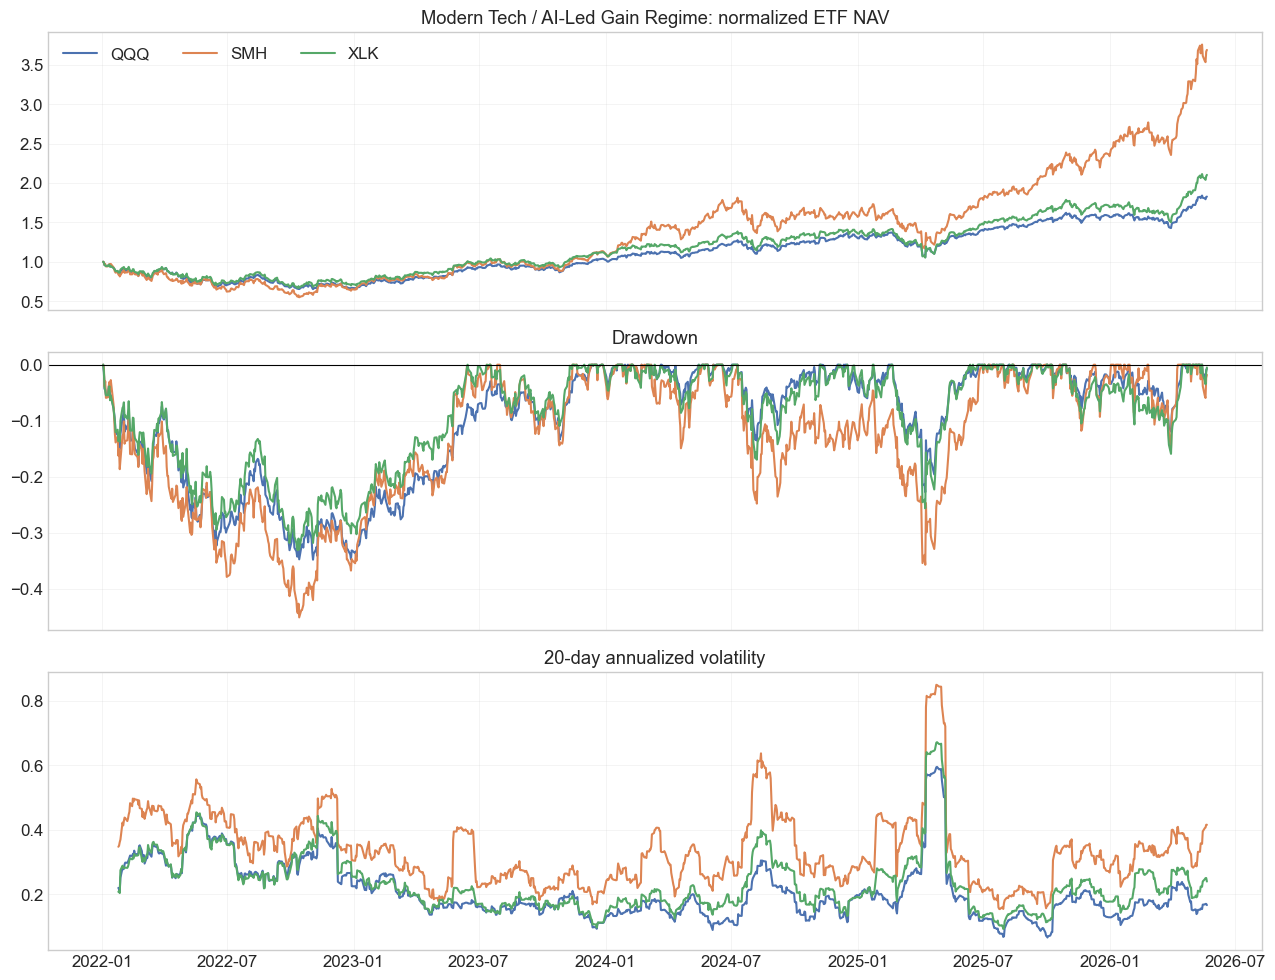

### ETF regime summary

,ticker,first_valid,last_valid,observations,total_return,annualized_vol,max_drawdown,worst_month,best_month
0,QQQ,2022-01-03,2026-05-21,1100,0.826521,0.23241,-0.348280,-0.135957,0.156901
1,SMH,2022-01-03,2026-05-21,1100,2.689260,0.36188,-0.451362,-0.167021,0.321648
2,XLK,2022-01-03,2026-05-21,1100,1.102737,0.25779,-0.331313,-0.119671,0.200151


### Stock availability screen

,ticker,first_valid,last_valid,lookback_days_before_start,target_observations,target_coverage,median_pre_dollar_volume_252d,passes_screen
37,TSLA,2014-01-02,2026-05-21,2015,1100,1.0,1.967126e+10,True
0,AAPL,2014-01-02,2026-05-21,2015,1100,1.0,1.126248e+10,True
5,AMZN,2014-01-02,2026-05-21,2015,1100,1.0,1.053605e+10,True
22,MSFT,2014-01-02,2026-05-21,2015,1100,1.0,6.336848e+09,True
27,NVDA,2014-01-02,2026-05-21,2015,1100,1.0,5.614997e+09,True
21,META,2014-01-02,2026-05-21,2015,1100,1.0,5.237105e+09,True
4,AMD,2014-01-02,2026-05-21,2015,1100,1.0,4.212164e+09,True
15,GOOGL,2014-01-02,2026-05-21,2015,1100,1.0,3.295081e+09,True
14,GOOG,2014-01-02,2026-05-21,2015,1100,1.0,2.790460e+09,True
25,NFLX,2014-01-02,2026-05-21,2015,1100,1.0,1.816189e+09,True


### Candidate proxy universe ranking

,candidate_universe,ticker_count,candidate_fit_score,corr_to_benchmark,beta_to_benchmark,equal_weight_total_return,equal_weight_annualized_vol,equal_weight_max_drawdown,avg_cross_sectional_daily_dispersion
0,top_liquidity_25,25,2.220071,0.945689,1.127931,1.759339,0.307468,-0.444899,0.020850
1,top_liquidity_40,40,1.859165,0.926404,1.125745,1.399263,0.313260,-0.408080,0.021123
2,all_screened_40,40,1.859165,0.926404,1.125745,1.399263,0.313260,-0.408080,0.021123
3,top_liquidity_15,15,1.828966,0.928482,1.110972,1.384741,0.308458,-0.485653,0.019972


### Recommended proxy universe: `top_liquidity_25`

,ticker
0,TSLA
1,AAPL
2,AMZN
3,MSFT
4,NVDA
5,META
6,AMD
7,GOOGL
8,GOOG
9,NFLX


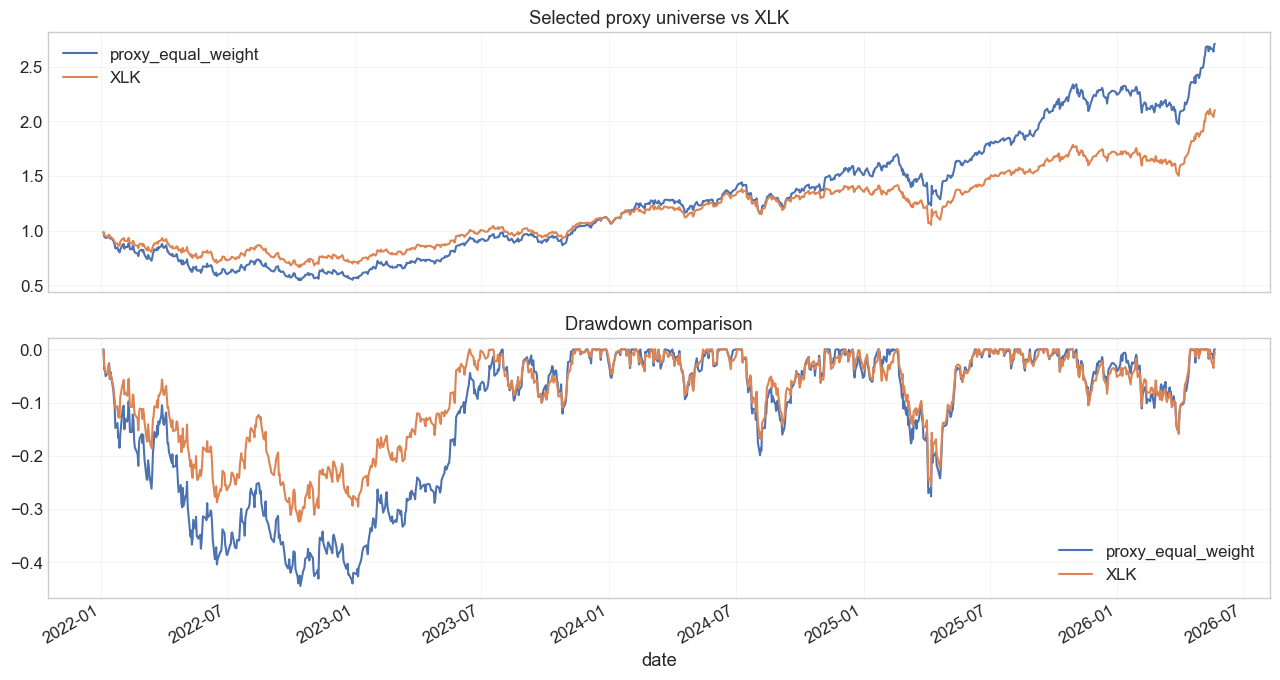

### Copy-paste TOML snippet

```toml
[modern_tech_gain_2022_2026]
name = "modern_tech_ai_led_gain_regime"
# Start-date-available proxy universe, not historical ETF holdings.
tickers = [
  "TSLA",
  "AAPL",
  "AMZN",
  "MSFT",
  "NVDA",
  "META",
  "AMD",
  "GOOGL",
  "GOOG",
  "NFLX",
  "SHOP",
  "MU",
  "CRM",
  "INTC",
  "ADBE",
  "PLTR",
  "QCOM",
  "UBER",
  "AMAT",
  "SNOW",
  "CSCO",
  "LRCX",
  "AVGO",
  "ORCL",
  "CRWD",
]
benchmark_ticker = "XLK"
default_benchmark = "XLK"
start_date = "2014-01-02"
end_date = "2026-05-21"
train_start = "2014-01-02"
train_end = "2019-12-31"
val_start = "2020-01-02"
val_end = "2021-12-31"
test_start = "2022-01-03"
test_end = "2026-05-21"
cost_bps = 10.0
```

In [6]:
modern_tech_gain_2022_2026_result = run_regime_research("modern_tech_gain_2022_2026", refresh=REFRESH_DOWNLOADS)

## Financial Crisis Loss Regime

## Financial Crisis Loss Regime

Target window: `2005-01-03` to `2010-12-31`. Benchmark: `XLF`.

$RYL: possibly delisted; no price data found  (1d 2000-01-03 -> 2011-01-01)
$NYCB: possibly delisted; no timezone found
$MDC: possibly delisted; no timezone found
$CTX: possibly delisted; no price data found  (1d 2000-01-03 -> 2011-01-01)
$CMA: possibly delisted; no timezone found

5 Failed downloads:
['RYL', 'CTX']: possibly delisted; no price data found  (1d 2000-01-03 -> 2011-01-01)
['NYCB', 'MDC', 'CMA']: possibly delisted; no timezone found


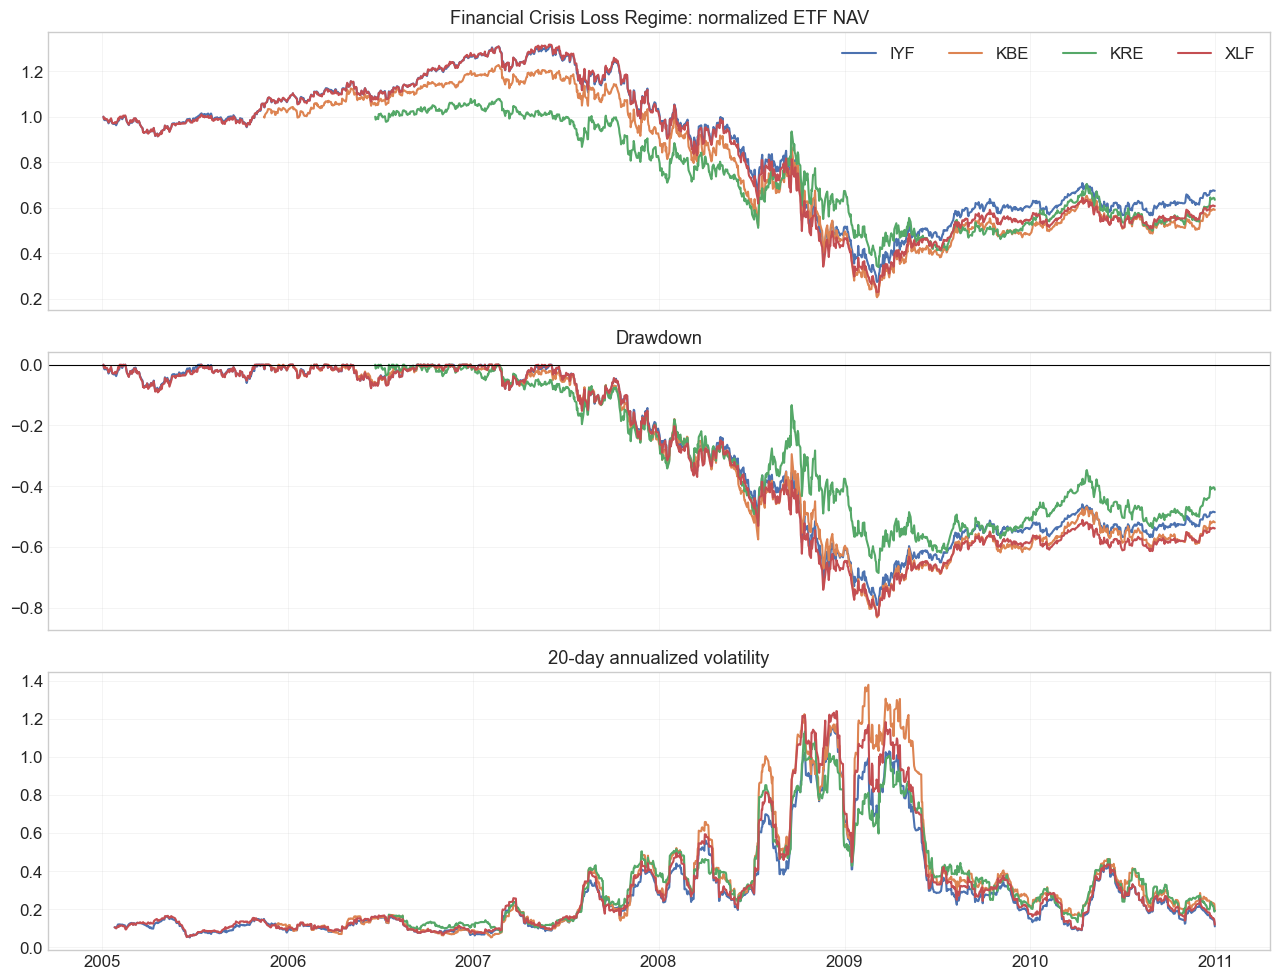

### ETF regime summary

,ticker,first_valid,last_valid,observations,total_return,annualized_vol,max_drawdown,worst_month,best_month
0,IYF,2005-01-03,2010-12-31,1511,-0.325301,0.377425,-0.790931,-0.238011,0.206296
3,XLF,2005-01-03,2010-12-31,1511,-0.392323,0.424502,-0.826865,-0.261981,0.217934
1,KBE,2005-11-15,2010-12-31,1291,-0.409164,0.495786,-0.831549,-0.351204,0.178211
2,KRE,2006-06-22,2010-12-31,1141,-0.365081,0.447853,-0.685395,-0.288751,0.178965


### Stock availability screen

,ticker,first_valid,last_valid,lookback_days_before_start,target_observations,target_coverage,median_pre_dollar_volume_252d,passes_screen
7,C,2000-01-03,2010-12-31,1256,1511,1.0,3.579002e+08,True
4,BAC,2000-01-03,2010-12-31,1256,1511,1.0,2.584696e+08,True
14,GS,2000-01-03,2010-12-31,1256,1511,1.0,2.339771e+08,True
1,AIG,2000-01-03,2010-12-31,1256,1511,1.0,2.094811e+08,True
18,JPM,2000-01-03,2010-12-31,1256,1511,1.0,1.932932e+08,True
16,HD,2000-01-03,2010-12-31,1256,1511,1.0,1.461567e+08,True
3,AXP,2000-01-03,2010-12-31,1256,1511,1.0,1.379526e+08,True
23,LOW,2000-01-03,2010-12-31,1256,1511,1.0,1.291785e+08,True
26,MS,2000-01-03,2010-12-31,1256,1511,1.0,1.219090e+08,True
41,WFC,2000-01-03,2010-12-31,1256,1511,1.0,1.141721e+08,True


### Candidate proxy universe ranking

,candidate_universe,ticker_count,candidate_fit_score,corr_to_benchmark,beta_to_benchmark,equal_weight_total_return,equal_weight_annualized_vol,equal_weight_max_drawdown,avg_cross_sectional_daily_dispersion
0,top_liquidity_15,15,1.480242,0.958516,0.999494,-0.130606,0.442650,-0.803981,0.018277
1,top_liquidity_25,25,1.370326,0.952647,1.020191,-0.026314,0.454599,-0.799498,0.020546
2,top_liquidity_38,38,1.331861,0.958121,1.038045,0.014301,0.459913,-0.783813,0.020745
3,all_screened_38,38,1.331861,0.958121,1.038045,0.014301,0.459913,-0.783813,0.020745


### Recommended proxy universe: `top_liquidity_15`

,ticker
0,C
1,BAC
2,GS
3,AIG
4,JPM
5,HD
6,AXP
7,LOW
8,MS
9,WFC


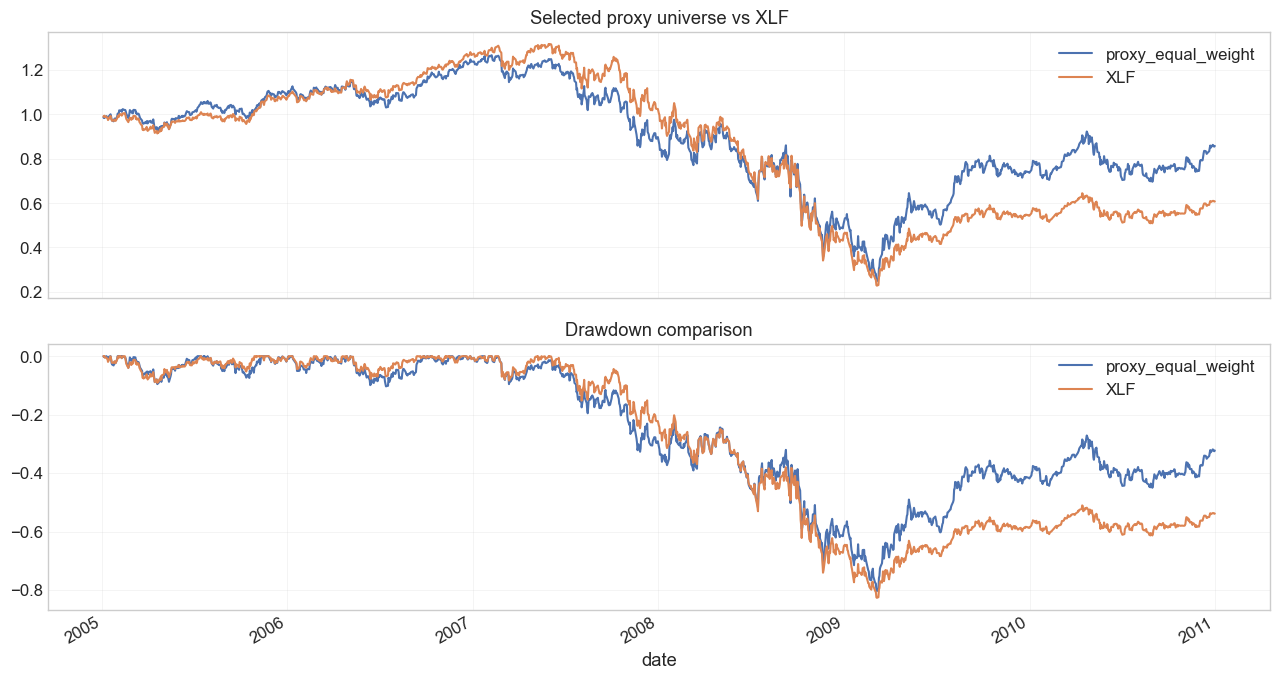

### Copy-paste TOML snippet

```toml
[financial_crisis_loss_2005_2010]
name = "financial_crisis_loss_regime"
# Start-date-available proxy universe, not historical ETF holdings.
tickers = [
  "C",
  "BAC",
  "GS",
  "AIG",
  "JPM",
  "HD",
  "AXP",
  "LOW",
  "MS",
  "WFC",
  "COF",
  "ALL",
  "USB",
  "LEN",
  "PHM",
]
benchmark_ticker = "XLF"
default_benchmark = "XLF"
start_date = "2000-01-03"
end_date = "2010-12-31"
train_start = "2000-01-03"
train_end = "2003-12-31"
val_start = "2004-01-02"
val_end = "2004-12-31"
test_start = "2005-01-03"
test_end = "2010-12-31"
cost_bps = 10.0
```

In [7]:
financial_crisis_loss_2005_2010_result = run_regime_research("financial_crisis_loss_2005_2010", refresh=REFRESH_DOWNLOADS)

## 1990s Volatility Regime

## 1990s High-Volatility / Late-Cycle Regime

Target window: `1995-05-05` to `1999-12-31`. Benchmark: `MDY`.

**Warning:** This window has limited ETF history before the regime. Treat it as regime research, not a full long-history train/val/test benchmark.

$SUNW: possibly delisted; no timezone found
$DELL: possibly delisted; no price data found  (1d 1992-05-05 -> 2000-01-01) (Yahoo error = "Data doesn't exist for startDate = 705038400, endDate = 946702800")
$GM: possibly delisted; no price data found  (1d 1992-05-05 -> 2000-01-01) (Yahoo error = "Data doesn't exist for startDate = 705038400, endDate = 946702800")
$CPQ: possibly delisted; no price data found  (1d 1992-05-05 -> 2000-01-01) (Yahoo error = "Data doesn't exist for startDate = 705038400, endDate = 946702800")

4 Failed downloads:
['SUNW']: possibly delisted; no timezone found
['DELL', 'GM', 'CPQ']: possibly delisted; no price data found  (1d 1992-05-05 -> 2000-01-01) (Yahoo error = "Data doesn't exist for startDate = 705038400, endDate = 946702800")


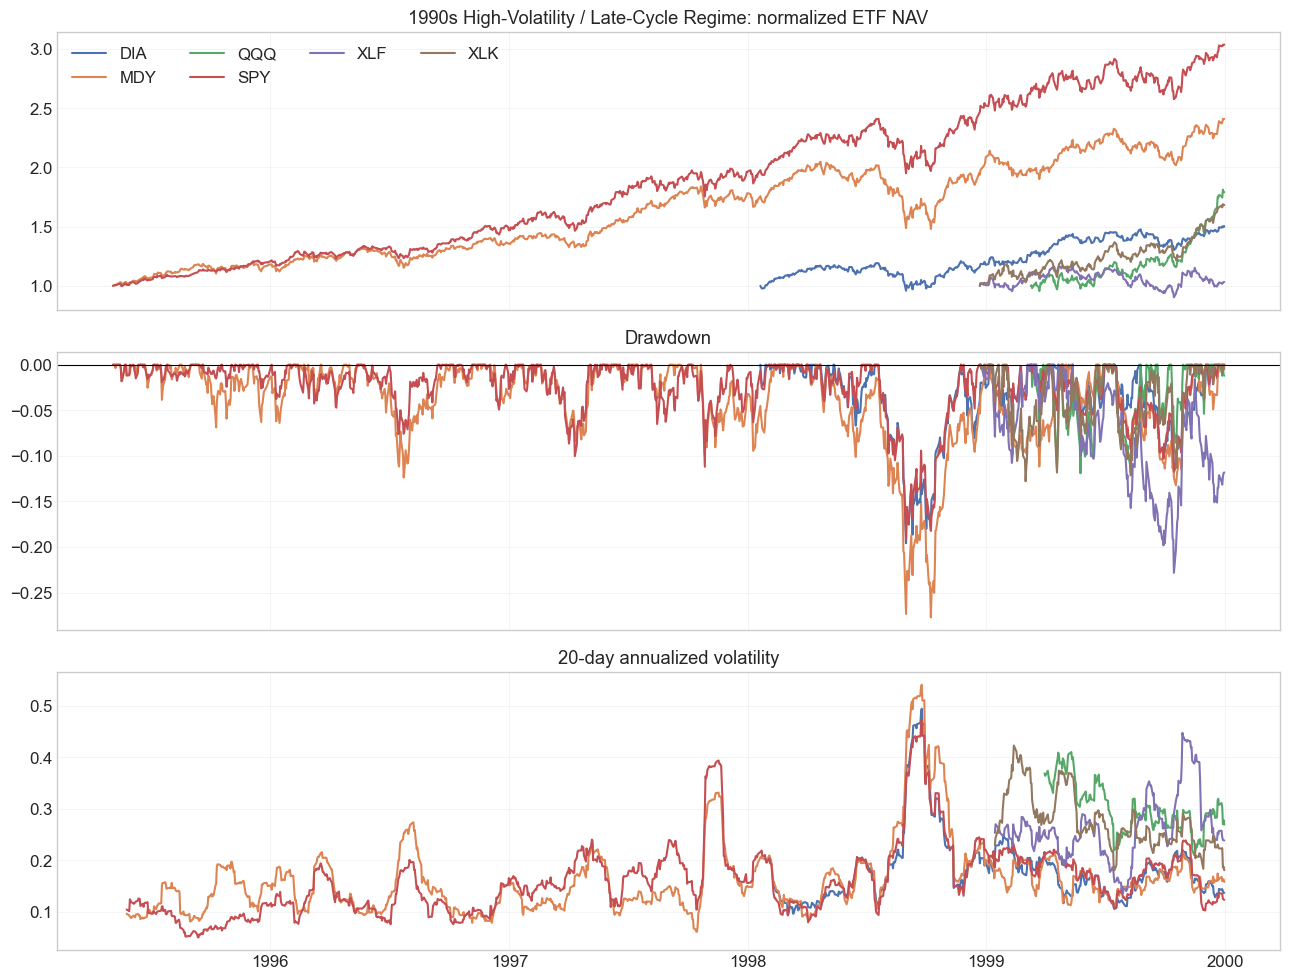

### ETF regime summary

,ticker,first_valid,last_valid,observations,total_return,annualized_vol,max_drawdown,worst_month,best_month
1,MDY,1995-05-05,1999-12-31,1177,1.410249,0.181753,-0.277309,-0.200468,0.125365
3,SPY,1995-05-05,1999-12-31,1177,2.036677,0.176133,-0.190301,-0.141180,0.081081
0,DIA,1998-01-20,1999-12-31,493,0.503984,0.198926,-0.195886,-0.152316,0.101211
4,XLF,1998-12-22,1999-12-31,259,0.032183,0.271461,-0.228365,-0.061078,0.155366
5,XLK,1998-12-22,1999-12-31,259,0.681164,0.282233,-0.127993,-0.099174,0.159004
2,QQQ,1999-03-10,1999-12-31,207,0.789474,0.312074,-0.119150,-0.031414,0.243197


### Stock availability screen

,ticker,first_valid,last_valid,lookback_days_before_start,target_observations,target_coverage,median_pre_dollar_volume_252d,passes_screen
22,INTC,1992-05-05,1999-12-31,759,1177,1.000000,1.608777e+08,True
31,MSFT,1992-05-05,1999-12-31,759,1177,1.000000,1.209977e+08,True
21,IBM,1992-05-05,1999-12-31,759,1177,1.000000,7.516538e+07,True
10,CSCO,1992-05-05,1999-12-31,759,1177,1.000000,6.521304e+07,True
32,ORCL,1992-05-05,1999-12-31,759,1177,1.000000,6.146997e+07,True
0,AAPL,1992-05-05,1999-12-31,759,1177,1.000000,5.275491e+07,True
16,GE,1992-05-05,1999-12-31,759,1177,1.000000,4.817288e+07,True
3,AMAT,1992-05-05,1999-12-31,759,1177,1.000000,4.443309e+07,True
39,TXN,1992-05-05,1999-12-31,759,1177,1.000000,3.665967e+07,True
44,WMT,1992-05-05,1999-12-31,759,1177,1.000000,3.577070e+07,True


### Candidate proxy universe ranking

,candidate_universe,ticker_count,candidate_fit_score,corr_to_benchmark,beta_to_benchmark,equal_weight_total_return,equal_weight_annualized_vol,equal_weight_max_drawdown,avg_cross_sectional_daily_dispersion
0,top_liquidity_25,25,0.783268,0.785738,0.881964,4.356201,0.204011,-0.206689,0.019512
1,top_liquidity_15,15,0.780882,0.739483,0.979054,5.688056,0.240635,-0.181293,0.020027
2,top_liquidity_40,40,0.773011,0.810616,0.831717,3.802922,0.186484,-0.205565,0.019449
3,top_liquidity_41,41,0.767281,0.809931,0.822307,3.748392,0.184530,-0.202320,0.019391
4,all_screened_41,41,0.767281,0.809931,0.822307,3.748392,0.184530,-0.202320,0.019391


### Recommended proxy universe: `top_liquidity_25`

,ticker
0,INTC
1,MSFT
2,IBM
3,CSCO
4,ORCL
5,AAPL
6,GE
7,AMAT
8,TXN
9,WMT


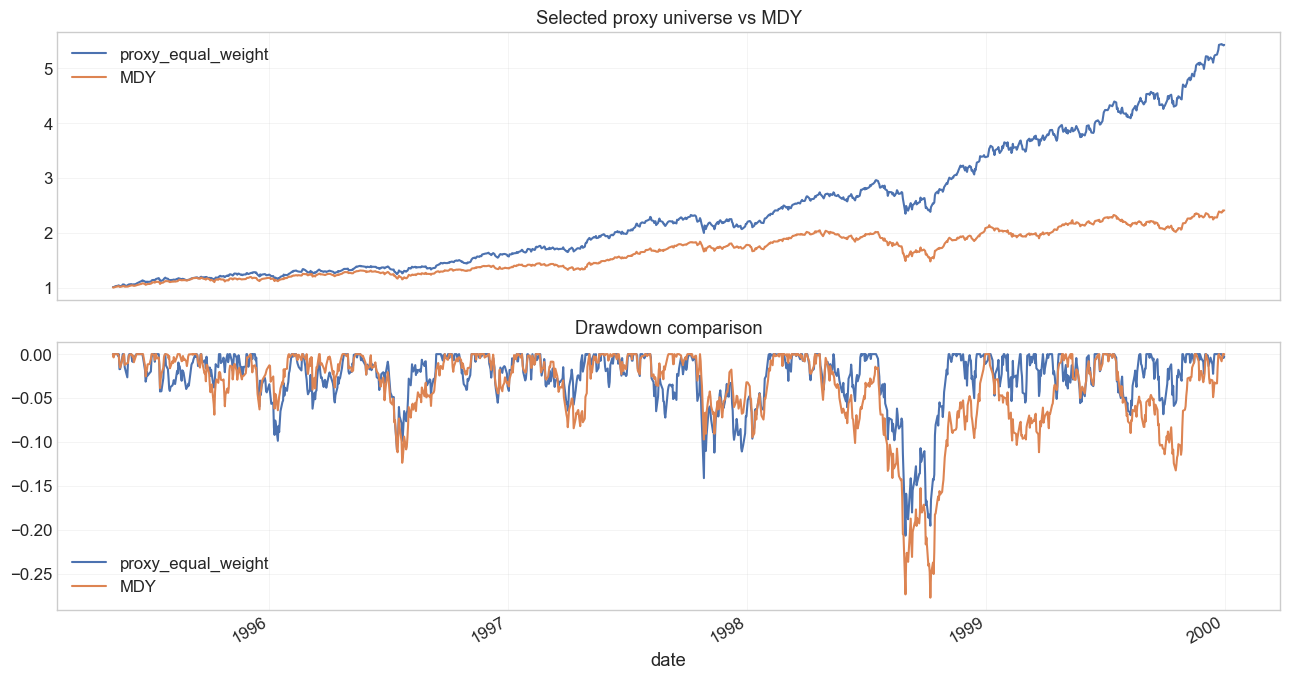

### Copy-paste TOML snippet

```toml
[nineties_volatility_1995_1999]
name = "1990s_high_volatility_late_cycle_regime"
# Start-date-available proxy universe, not historical ETF holdings.
tickers = [
  "INTC",
  "MSFT",
  "IBM",
  "CSCO",
  "ORCL",
  "AAPL",
  "GE",
  "AMAT",
  "TXN",
  "WMT",
  "DIS",
  "KO",
  "HPQ",
  "MRK",
  "JNJ",
  "HD",
  "AXP",
  "F",
  "ADBE",
  "PEP",
  "AIG",
  "XOM",
  "BA",
  "MCD",
  "PG",
]
benchmark_ticker = "MDY"
default_benchmark = "MDY"
start_date = "1995-05-05"
end_date = "1999-12-31"
train_start = "1995-05-05"
train_end = "1996-12-31"
val_start = "1997-01-02"
val_end = "1997-12-31"
test_start = "1998-01-02"
test_end = "1999-12-31"
cost_bps = 10.0
```

In [8]:
nineties_volatility_1995_1999_result = run_regime_research("nineties_volatility_1995_1999", refresh=REFRESH_DOWNLOADS)

## Oil Crash Regime

## Oil / Energy Crash Regime

Target window: `2014-06-02` to `2016-12-30`. Benchmark: `XOP`.

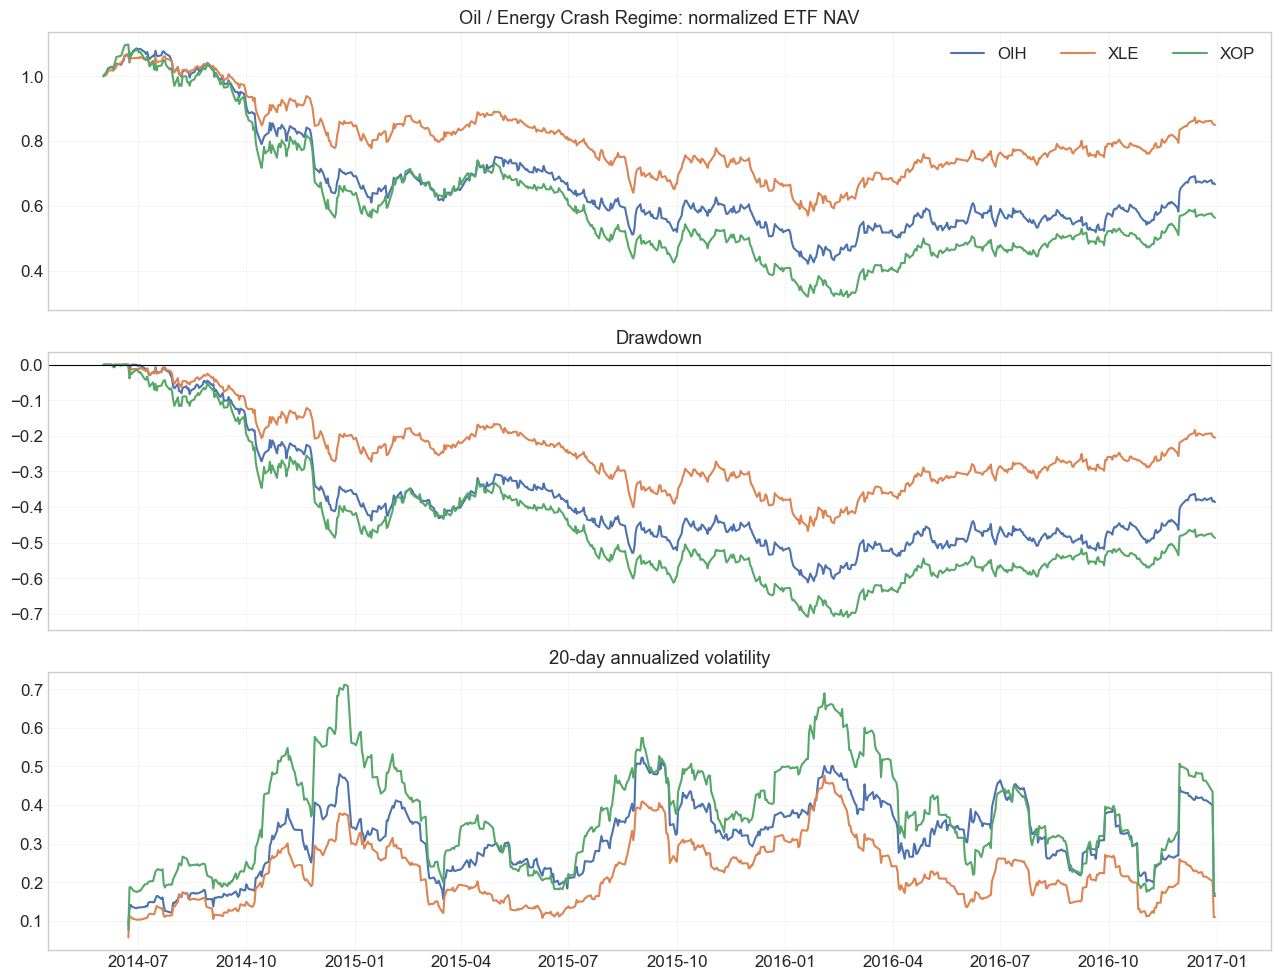

### ETF regime summary

,ticker,first_valid,last_valid,observations,total_return,annualized_vol,max_drawdown,worst_month,best_month
0,OIH,2014-06-02,2016-12-30,653,-0.333541,0.332586,-0.612524,-0.156195,0.164945
1,XLE,2014-06-02,2016-12-30,653,-0.150779,0.240353,-0.467458,-0.105170,0.111601
2,XOP,2014-06-02,2016-12-30,653,-0.437151,0.403816,-0.710456,-0.182146,0.237176


### Stock availability screen

,ticker,first_valid,last_valid,lookback_days_before_start,target_observations,target_coverage,median_pre_dollar_volume_252d,passes_screen
32,XOM,2010-01-04,2016-12-30,1109,653,1.0,6.306884e+08,True
5,CVX,2010-01-04,2016-12-30,1109,653,1.0,3.918631e+08,True
27,SLB,2010-01-04,2016-12-30,1109,653,1.0,3.528159e+08,True
12,HAL,2010-01-04,2016-12-30,1109,653,1.0,3.251484e+08,True
4,COP,2010-01-04,2016-12-30,1109,653,1.0,2.330626e+08,True
22,OXY,2010-01-04,2016-12-30,1109,653,1.0,2.329277e+08,True
9,EOG,2010-01-04,2016-12-30,1109,653,1.0,2.044639e+08,True
29,VLO,2010-01-04,2016-12-30,1109,653,1.0,2.020471e+08,True
19,NOV,2010-01-04,2016-12-30,1109,653,1.0,1.894934e+08,True
0,APA,2010-01-04,2016-12-30,1109,653,1.0,1.774276e+08,True


### Candidate proxy universe ranking

,candidate_universe,ticker_count,candidate_fit_score,corr_to_benchmark,beta_to_benchmark,equal_weight_total_return,equal_weight_annualized_vol,equal_weight_max_drawdown,avg_cross_sectional_daily_dispersion
0,top_liquidity_25,25,1.403386,0.933498,0.678471,-0.180905,0.293496,-0.552692,0.016523
1,all_screened_25,25,1.403386,0.933498,0.678471,-0.180905,0.293496,-0.552692,0.016523
2,top_liquidity_15,15,1.266076,0.933900,0.630267,-0.148410,0.272526,-0.474630,0.014548


### Recommended proxy universe: `top_liquidity_25`

,ticker
0,XOM
1,CVX
2,SLB
3,HAL
4,COP
5,OXY
6,EOG
7,VLO
8,NOV
9,APA


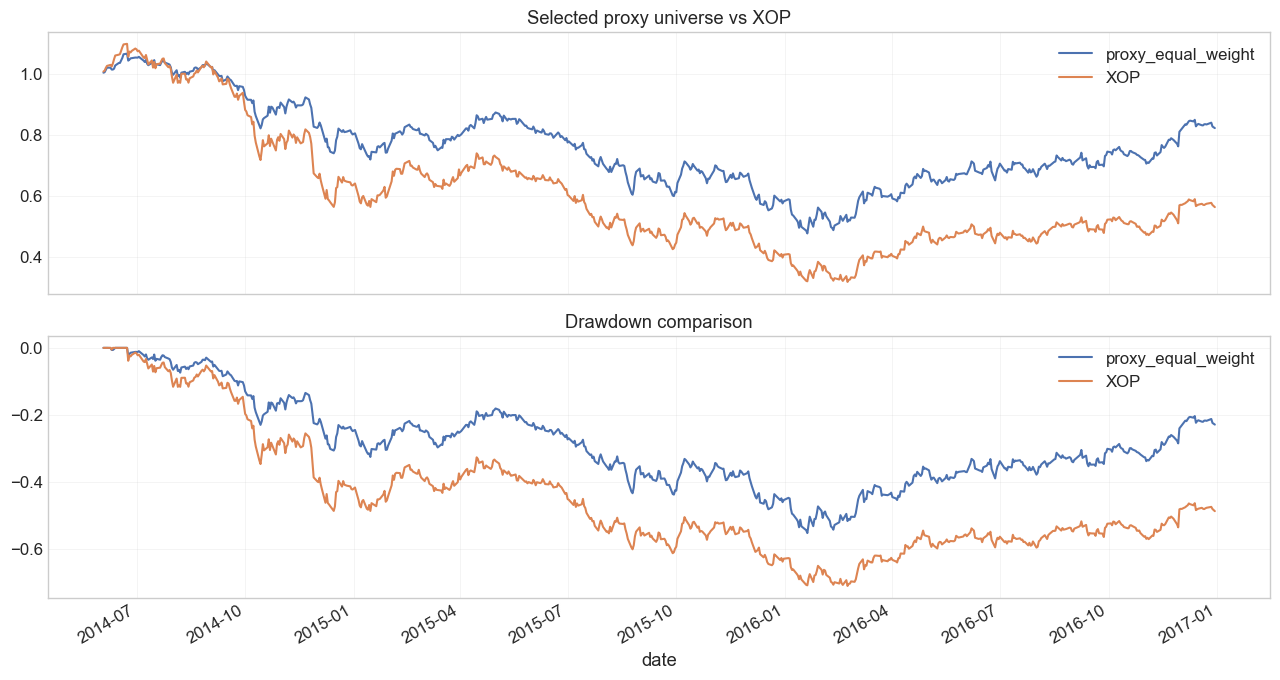

### Copy-paste TOML snippet

```toml
[oil_crash_2014_2016]
name = "oil_energy_crash_regime"
# Start-date-available proxy universe, not historical ETF holdings.
tickers = [
  "XOM",
  "CVX",
  "SLB",
  "HAL",
  "COP",
  "OXY",
  "EOG",
  "VLO",
  "NOV",
  "APA",
  "MPC",
  "RIG",
  "PSX",
  "DVN",
  "RRC",
  "WMB",
  "EQT",
  "BKR",
  "KMI",
  "CNX",
  "FTI",
  "NBR",
  "OII",
  "HP",
  "OKE",
]
benchmark_ticker = "XOP"
default_benchmark = "XOP"
start_date = "2010-01-04"
end_date = "2013-12-30"
train_start = "2010-01-04"
train_end = "2012-12-31"
val_start = "2010-01-04"
val_end = "2013-12-31"
test_start = "2010-01-04"
test_end = "2013-12-31"
cost_bps = 10.0
```

In [14]:
oil_crash_2014_2016_result = run_regime_research("oil_crash_2014_2016", refresh=REFRESH_DOWNLOADS)

## Combined Recommendation Table

In [ ]:
all_results = [
    modern_tech_gain_2022_2026_result,
    financial_crisis_loss_2005_2010_result,
    nineties_volatility_1995_1999_result,
    oil_crash_2014_2016_result,
]

summary_rows = []
for payload in all_results:
    top = payload["universe_scores"].iloc[0]
    summary_rows.append({
        "dataset_key": payload["regime_key"],
        "title": payload["regime"]["title"],
        "benchmark": payload["regime"]["benchmark"],
        "target_start": payload["regime"]["target_start"],
        "target_end": payload["regime"]["target_end"],
        "selected_universe": top["candidate_universe"],
        "ticker_count": top["ticker_count"],
        "corr_to_benchmark": top["corr_to_benchmark"],
        "beta_to_benchmark": top["beta_to_benchmark"],
        "equal_weight_total_return": top["equal_weight_total_return"],
        "equal_weight_annualized_vol": top["equal_weight_annualized_vol"],
        "equal_weight_max_drawdown": top["equal_weight_max_drawdown"],
    })
combined_recommendations = pd.DataFrame(summary_rows)
display(combined_recommendations)

print("\n# Copy-paste TOML snippets")
for payload in all_results:
    print("\n" + payload["toml"] + "\n")

## Interpretation Notes

- These are **start-date-available proxy universes**, not historical ETF holdings.
- Passing the availability screen means the ticker had price data before the regime start and enough target-window coverage. It does not prove that the stock was an ETF constituent at the time.
- Older windows, especially the 1990s regime, are useful for stress/regime research but may not support the same long train/validation/test split style as the modern datasets.
- If a selected universe looks too biased after inspecting the charts, prefer manually choosing a lower-ranked candidate universe with broader coverage rather than adding current ETF holdings.